# 04 Customer Analysis RFM

- **Recency (R):** Days since the customer's last purchase (relative to a fixed reference date — usually one day after the dataset's max date).
- **Frequency (F):** Number of distinct orders (invoices) the customer placed.
- **Monetary (M):** Total revenue from that customer.


In [10]:
import pandas as pd

df_clean = pd.read_csv("C:\\Users\\Siddhesh\\Downloads\\Projects\\E-commerce\\ecommerce-sales-customer-intelligence\\data\\retail_clean.csv")

print(df_clean.shape)
df_clean.head()

(19469, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,YearMonth,IsCancelled
0,555150,22762,CUPBOARD 3 DRAWER MA CAMPAGNE,1,2011-05-31 15:53:00,29.17,NaN,United Kingdom,29.17,2011,5,2011-05,False
1,575477,22645,CERAMIC HEART FAIRY CAKE MONEY BANK,1,2011-11-09 16:14:00,3.29,NaN,United Kingdom,3.29,2011,11,2011-11,False
2,538177,84596E,SMALL LICORICE DES PINK BOWL,1,2010-12-10 09:51:00,2.51,NaN,United Kingdom,2.51,2010,12,2010-12,False
3,575930,23378,PACK OF 12 50'S CHRISTMAS TISSUES,1,2011-11-11 17:58:00,0.83,NaN,United Kingdom,0.83,2011,11,2011-11,False
4,546890,22084,PAPER CHAIN KIT EMPIRE,6,2011-03-17 18:18:00,2.95,13394.0,United Kingdom,17.70,2011,3,2011-03,False


In [11]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['InvoiceDate'].dtype

dtype('<M8[us]')

In [12]:
import pandas as pd
import datetime as dt

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create snapshot date
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

print("Snapshot Date:", snapshot_date)
print(df_clean['InvoiceDate'].dtype)

Snapshot Date: 2011-12-10 12:50:00
datetime64[us]


In [13]:
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

In [14]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)  # lower recency = better = 5
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [15]:
def segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r == 3 and f <= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost Customers'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm['Segment'].value_counts()

Segment
Loyal Customers        745
Lost Customers         686
Champions              548
At Risk                515
New Customers          261
Potential Loyalists    259
Name: count, dtype: int64

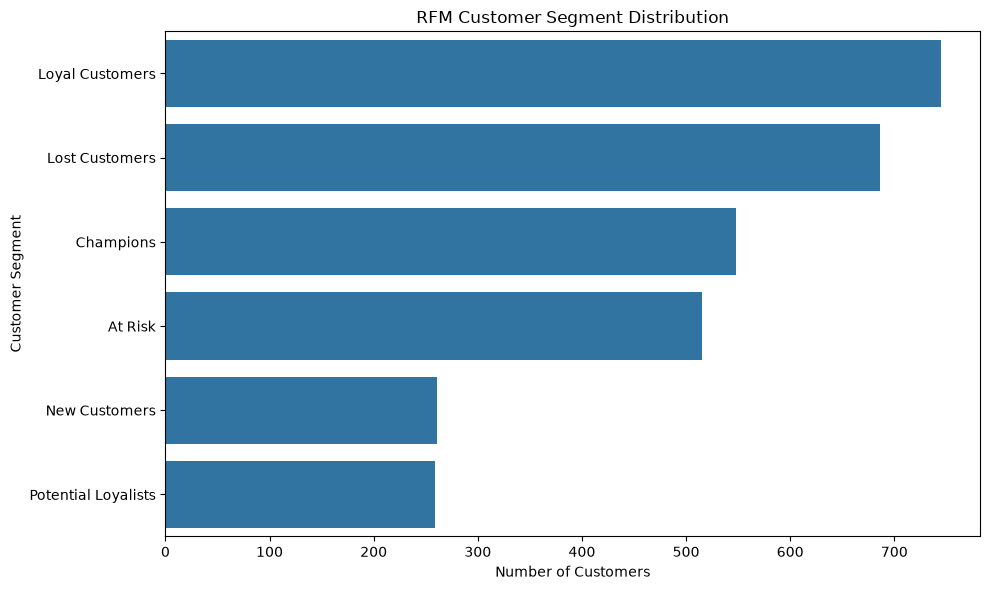

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title('RFM Customer Segment Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()